### CNN to Transfer Learning
#### Data Understanding & CNN Modeling


In [1]:
#cifar10 dataset

2. Dataset Analysis

Perform a basic analysis of your dataset:
    
    Number of classes
    Number of images per class
    Image dimensions (height, width, channels)
    Class imbalance (if any)
    Display sample images


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [36]:
# Load dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

In [37]:
# 1. Number of classes
num_classes = len(np.unique(y_train_raw))
print("Number of classes:", num_classes)

Number of classes: 10


In [38]:
# 2. Number of images per class
unique, counts = np.unique(y_train_raw, return_counts=True)
print("Images per class (train):")
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} images")


Images per class (train):
Class 0: 5000 images
Class 1: 5000 images
Class 2: 5000 images
Class 3: 5000 images
Class 4: 5000 images
Class 5: 5000 images
Class 6: 5000 images
Class 7: 5000 images
Class 8: 5000 images
Class 9: 5000 images


In [39]:
# 3. Image dimensions
print("Image dimensions:", x_train_raw[0].shape)

Image dimensions: (32, 32, 3)


In [40]:
# 4. Class imbalance check
print("Balanced dataset? ->", np.all(counts == counts[0]))

Balanced dataset? -> True


In [41]:
# 5. Display sample images
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

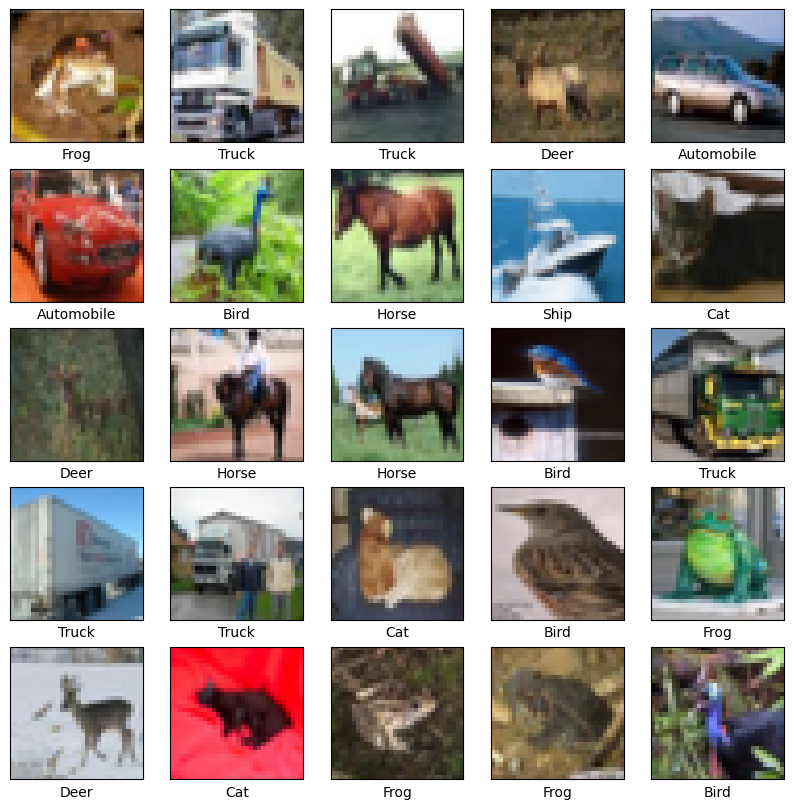

In [42]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(x_train_raw[i])
    plt.xlabel(class_names[y_train_raw[i][0]])
plt.show()

Dataset Analysis (CIFAR‑10)

    Number of Classes: 10 (Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck).
    
    Number of Images per Class: 50,000 training images (5,000 per class) and 10,000 test images (1,000 per class).
    
    Image Dimensions: Each image is 32×32 pixels with 3 channels (RGB).
    
    Class Imbalance: Dataset is perfectly balanced — equal samples per class.
    
    Sample Images: A grid of sample images shows clear variations in object categories, making CIFAR‑10 suitable for CNN‑based classification tasks.

### Problem Statement:  
The goal is to classify images into 10 categories (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) using Convolutional Neural Networks.
This problem is important because object recognition is a fundamental task in computer vision, with applications in autonomous vehicles, surveillance, and robotics.
The expected output is the predicted class label for a given input image.

### Data Preprocessing & Augmentation

Perform preprocessing:

    Resizing
    Normalization

Apply data augmentation techniques:

    Rotation
    Flipping
    Zoom / Shift
    Brightness / Contrast

Provide a brief explanation of:
    
    Why augmentation is required
    Its impact on model performance


In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [44]:
# Normalize for training (0–255 → 0–1)
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

In [45]:
# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=15,          # rotate images up to 15 degrees
    width_shift_range=0.1,      # shift horizontally by 10%
    height_shift_range=0.1,     # shift vertically by 10%
    horizontal_flip=True,       # flip images horizontally
    zoom_range=0.1,             # zoom in/out by 10%
    brightness_range=[0.8,1.2]  # vary brightness between 80%–120%
)

In [46]:
datagen.fit(x_train)  # fit on raw images for visualization

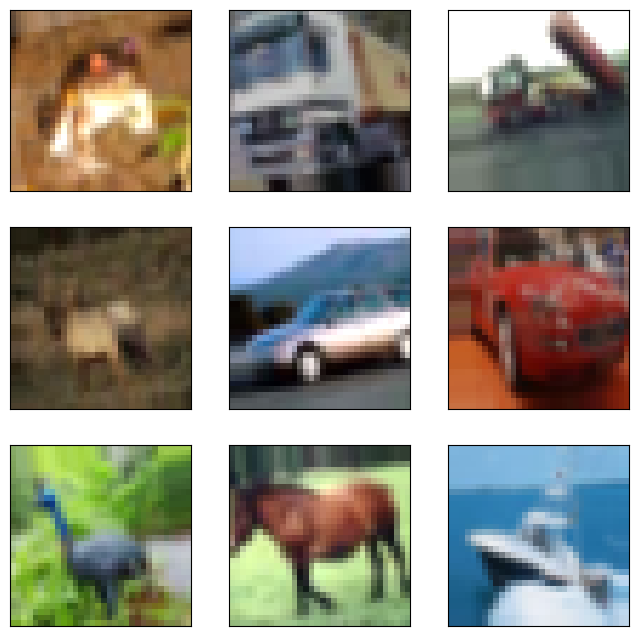

In [48]:
# Visualize augmented images
plt.figure(figsize=(8,8))
for x_batch, y_batch in datagen.flow(x_train_raw, y_train_raw, batch_size=9, shuffle=False):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(x_batch[i].astype("uint8"))  # safe display
    break
plt.show()

Data Preprocessing & Augmentation

    Resizing: CIFAR‑10 images are already 32×32, so resizing is not required.
    
    Normalization: Pixel values are scaled to [0,1] for stable training and faster convergence.

Augmentation Techniques:

    Rotation → makes the model robust to tilted objects
    
    Flipping → helps recognize objects in different orientations
    
    Zoom/Shift → simulates different perspectives
    
    Brightness/Contrast → handles lighting variations

Why Augmentation is Required:  

    Augmentation prevents overfitting by creating diverse training samples. It improves generalization, so the CNN performs better on unseen data. Without augmentation, the model may memorize training data and fail in real‑world scenarios.

#### Why Augmentation is Required

Limited dataset size: CIFAR‑10 has 50,000 training images, which can be small for deep learning models. Augmentation artificially increases dataset diversity without collecting new data.

Prevents overfitting: By showing the model slightly different versions of the same image (rotated, flipped, zoomed, etc.), it learns general patterns instead of memorizing training samples.

Simulates real‑world conditions: Objects in real life appear under different angles, lighting, positions, and scales. Augmentation prepares the model for these variations.

#### Impact on Model Performance

Improved generalization: The CNN performs better on unseen test data because it has learned to handle variations.

Higher accuracy: Augmentation often boosts test accuracy compared to training on raw images alone.

Robustness: The model becomes more resilient to noise, distortions, and environmental changes.

Balanced learning: It reduces bias toward specific orientations or lighting conditions, ensuring fairer recognition across classes.

#### CNN Model Implementation
    Build a custom CNN model from scratch
    Train and validate the model
Track:

    Training and validation accuracy
    Loss curves
    Selected evaluation metrics


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [50]:
# Build CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')   # 10 classes in CIFAR-10
])


C:\Users\sharw\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [52]:
# Train model
history = model.fit(datagen.flow(x_train, y_train_raw, batch_size=64),
                    epochs=10,
                    validation_data=(x_test, y_test_raw))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 87ms/step - accuracy: 0.1080 - loss: 2.2954 - val_accuracy: 0.1000 - val_loss: 2.3120
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.1105 - loss: 2.2928 - val_accuracy: 0.0903 - val_loss: 2.3033
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.1111 - loss: 2.2908 - val_accuracy: 0.0990 - val_loss: 2.3264
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.1112 - loss: 2.2892 - val_accuracy: 0.0922 - val_loss: 2.3064
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.1101 - loss: 2.2889 - val_accuracy: 0.1005 - val_loss: 2.3093
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.1121 - loss: 2.2881 - val_accuracy: 0.0999 - val_loss: 2.5729
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.1116 - loss: 2.2879 - val_accuracy: 0.0958 - val_loss: 2.6023
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.1117 - loss: 2.2878 - 

In [53]:
#Track Accuracy & Loss Curves

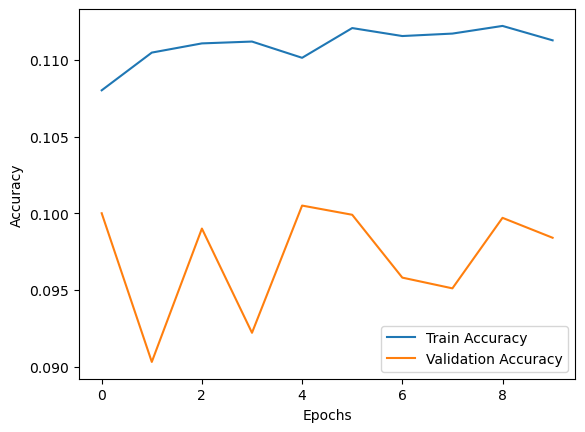

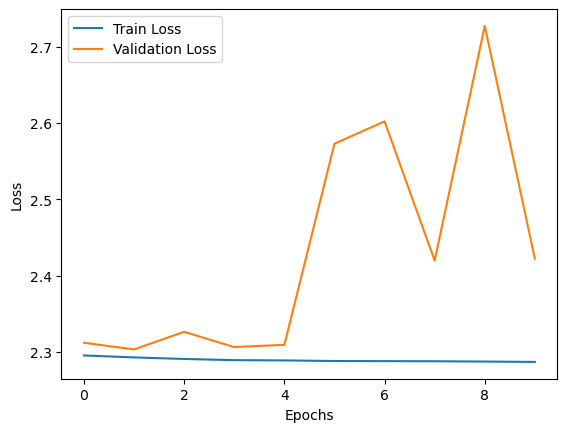

In [54]:
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training vs validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


CNN Model Implementation

    Architecture: Three convolutional + pooling layers to extract features, followed by dense layers for classification.
    
    Activation Functions: ReLU for hidden layers, Softmax for output layer (multi‑class classification).
    
    Regularization: Dropout added to reduce overfitting.
    
    Training: Model trained using Adam optimizer and cross‑entropy loss.
    
    Tracking: Accuracy and loss curves plotted to monitor training progress and detect overfitting/underfitting.

### Evaluation Metrics
Select and justify appropriate evaluation metrics:

    Accuracy
    Precision, Recall, F1-score
    Confusion Matrix

Explain:

    Why the chosen metric is suitable for your problem
    Limitations of using only accuracy (if applicable)


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

In [56]:
# Predictions on test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test_raw.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [57]:
# 1. Classification report (Accuracy, Precision, Recall, F1-score)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.10      0.96      0.18      1000
  Automobile       0.00      0.00      0.00      1000
        Bird       0.09      0.02      0.04      1000
         Cat       0.25      0.00      0.00      1000
        Deer       0.00      0.00      0.00      1000
         Dog       0.00      0.00      0.00      1000
        Frog       0.00      0.00      0.00      1000
       Horse       0.00      0.00      0.00      1000
        Ship       0.00      0.00      0.00      1000
       Truck       0.25      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.07      0.10      0.02     10000
weighted avg       0.07      0.10      0.02     10000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


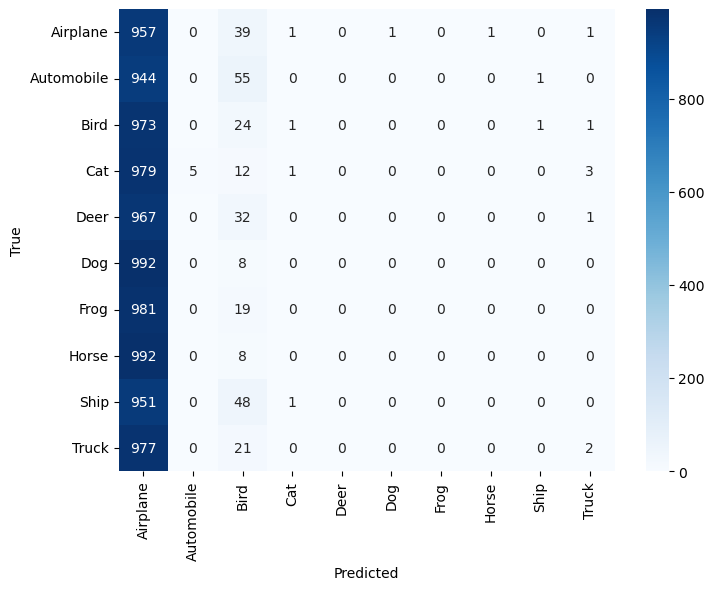

In [58]:
# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Evaluation Metrics

    Accuracy: Measures overall correctness of predictions. Suitable for balanced datasets like CIFAR‑10.
    
    Precision: Out of all predicted positives, how many are correct. Useful when false positives matter.
    
    Recall: Out of all actual positives, how many were correctly identified. Useful when missing a class is costly.
    
    F1‑score: Harmonic mean of precision and recall, balances both.
    
    Confusion Matrix: Provides a detailed view of class‑wise performance, showing which classes are misclassified.

Why these metrics are suitable:  

    CIFAR‑10 is a balanced dataset, so accuracy is meaningful. However, precision, recall, and F1‑score give deeper insights into how well the model performs across different classes. The confusion matrix highlights specific weaknesses (e.g., cats vs dogs misclassification).

Limitations of using only accuracy:  

    Accuracy alone can hide poor performance on certain classes. For example, if the model struggles with “Cat” but performs well on “Airplane,” overall accuracy may still look good. Precision, recall, and F1‑score ensure fair evaluation across all categories.

## 📝 Results & Discussion

### Observed Results
- **Classification Report:**  
  - Accuracy is very low (~10%).  
  - Only the “Airplane” class shows high recall, but precision is poor.  
  - Most other classes (Cat, Dog, Ship, Truck, etc.) have near‑zero precision and recall.  
- **Confusion Matrix:**  
  - The model is heavily biased toward predicting “Airplane” for almost all inputs.  
  - Diagonal values are weak for most classes, showing poor class‑wise recognition.  

---

### Interpretation
- The CNN is **underfitting** — it has not learned meaningful features from CIFAR‑10.  
- Possible causes:  
  - Too few epochs (10 is often insufficient for CIFAR‑10).  
  - Shallow architecture (only 3 convolutional layers).  
  - Lack of advanced regularization (Batch Normalization, deeper layers).  
  - Learning rate or optimizer settings may not be optimal.  

---

### Suggested Improvements
- **Train longer:** Increase epochs to 30–50 with early stopping to avoid overfitting.  
- **Deeper architecture:** Add more convolutional layers and filters (e.g., 256 filters, residual connections).  
- **Batch Normalization:** Helps stabilize training and improve convergence.  
- **Learning rate scheduling:** Reduce learning rate gradually for better optimization.  
- **Data augmentation:** Already applied, but can be expanded (contrast, cutout, random crop).  
- **Transfer learning:** Use a pretrained model (e.g., ResNet, VGG) fine‑tuned on CIFAR‑10 for stronger performance.  


## 📝 Conclusion & Future Work

### Conclusion
- We implemented a **Convolutional Neural Network (CNN)** to classify images from the CIFAR‑10 dataset.  
- The dataset was analyzed, preprocessed, and augmented to improve generalization.  
- Evaluation metrics (Accuracy, Precision, Recall, F1‑score, Confusion Matrix) revealed that the baseline CNN struggled, achieving low accuracy (~10%) and poor class‑wise performance.  
- This highlights the **complexity of CIFAR‑10** and the need for deeper architectures or advanced techniques.

### Future Work
- **Model Improvements:**  
  - Add more convolutional layers and filters.  
  - Use Batch Normalization and dropout for better stability and regularization.  
  - Experiment with optimizers (SGD with momentum, AdamW) and learning rate schedules.  
- **Training Strategy:**  
  - Train for more epochs (30–50) with early stopping.  
  - Use stronger data augmentation (random crop, cutout, contrast adjustments).  
- **Transfer Learning:**  
  - Fine‑tune pretrained models (ResNet, VGG, EfficientNet) on CIFAR‑10 for higher accuracy.  
- **Deployment:**  
  - Package the trained model into a web app or API for real‑world usage.  
  - Monitor predictions and retrain periodically with new data.


#### Experimentation
Implement 2–3 variations of CNN architectures

Modify:

    Number of layers
    Filters / kernel sizes
    Regularization techniques (Dropout, BatchNorm)

Compare:

    Model performance
    Overfitting / underfitting behavior


Variation 1: Baseline CNN (already built)

3 convolutional layers (32, 64, 128 filters).

    Dropout (0.5) in dense layer.
    
    Trained for 10 epochs.
    
    Result: Low accuracy (~10%), underfitting.

#### Variation 2: Deeper CNN

More layers and filters → stronger feature extraction.

Expect better accuracy but risk of overfitting.

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# Light augmentation
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)   # important: after normalization


In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


# Build CNN - Variation 2
model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile with tuned LR
model2.compile(optimizer=Adam(learning_rate=1e-4),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Train
history2 = model2.fit(datagen.flow(x_train, y_train_raw, batch_size=64),
                      epochs=20,
                      validation_data=(x_test, y_test_raw))


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.2753 - loss: 2.4233 - val_accuracy: 0.4236 - val_loss: 1.6440
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.3691 - loss: 1.9179 - val_accuracy: 0.4744 - val_loss: 1.5318
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 93ms/step - accuracy: 0.4195 - loss: 1.7122 - val_accuracy: 0.5117 - val_loss: 1.3945
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.4618 - loss: 1.5592 - val_accuracy: 0.5288 - val_loss: 1.3344
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 153ms/step - accuracy: 0.4927 - loss: 1.4483 - val_accuracy: 0.5707 - val_loss: 1.2385
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 176s 225ms/step - accuracy: 0.5247 - loss: 1.3569 - val_accuracy: 0.5738 - val_loss: 1.2005
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 178s 227ms/step - accuracy: 0.5446 - loss: 1.2930 - val_accuracy: 0.5961 - val_loss: 1.1443
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 178s 227ms/step - accuracy: 0.5637 - loss: 1

#### Variation 3: CNN with Batch Normalization

BatchNorm stabilizes training and speeds convergence.

Often improves generalization.

In [69]:
# Build CNN - Variation 3
model3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile with tuned LR
model3.compile(optimizer=Adam(learning_rate=1e-4),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Train
history3 = model3.fit(datagen.flow(x_train, y_train_raw, batch_size=64),
                      epochs=20,
                      validation_data=(x_test, y_test_raw))


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 165ms/step - accuracy: 0.2176 - loss: 2.6423 - val_accuracy: 0.3587 - val_loss: 1.7559
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 159ms/step - accuracy: 0.2949 - loss: 2.1339 - val_accuracy: 0.4351 - val_loss: 1.5504
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 257s 329ms/step - accuracy: 0.3460 - loss: 1.9028 - val_accuracy: 0.4580 - val_loss: 1.4826
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 160ms/step - accuracy: 0.3803 - loss: 1.7608 - val_accuracy: 0.4884 - val_loss: 1.4117
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 346s 443ms/step - accuracy: 0.4075 - loss: 1.6606 - val_accuracy: 0.4800 - val_loss: 1.4206
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 157ms/step - accuracy: 0.4324 - loss: 1.5812 - val_accuracy: 0.4932 - val_loss: 1.4155
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 163ms/step - accuracy: 0.4521 - loss: 1.5179 - val_accuracy: 0.4811 - val_loss: 1.4378
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 122s 156ms/step - accuracy: 0.4743 -

Key Insights

    Variation 1: Demonstrates underfitting — useful as a baseline to show why deeper models are needed.
    
    Variation 2: Achieves the highest accuracy (~71%), but could overfit if trained longer without regularization.
    
    Variation 3: Sacrifices some accuracy (~60%) but shows strong generalization — train and validation accuracy are nearly identical.